COVID-19 Spread Modelling

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base_url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/" # loading from Internet
# base_url = "../../data/COVID/" # loading from disk
infected_dataset_url = base_url + "time_series_covid19_confirmed_global.csv"
recovered_dataset_url = base_url + "time_series_covid19_recovered_global.csv"
deaths_dataset_url = base_url + "time_series_covid19_deaths_global.csv"
countries_dataset_url = base_url + "../UID_ISO_FIPS_LookUp_Table.csv"

infected = pd.read_csv(infected_dataset_url)
recovered = pd.read_csv(recovered_dataset_url)
deaths = pd.read_csv(deaths_dataset_url)
countries = pd.read_csv(countries_dataset_url)

infected = infected.groupby('Country/Region').sum()
recovered = recovered.groupby('Country/Region').sum()
deaths = deaths.groupby('Country/Region').sum()

infected.drop(columns=['Lat','Long','Province/State'],inplace=True)
recovered.drop(columns=['Lat','Long','Province/State'],inplace=True)
deaths.drop(columns=['Lat','Long','Province/State'],inplace=True)

question 1: Plot Rt graphs for 5-6 different countries on one plot for comparison, or using several plots side-by-side

C:\Users\Owner\AppData\Local\Temp\ipykernel_17240\2670093491.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  inner_df.index = pd.to_datetime(inner_df.index)
C:\Users\Owner\AppData\Local\Temp\ipykernel_17240\2670093491.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  inner_df.index = pd.to_datetime(inner_df.index)
C:\Users\Owner\AppData\Local\Temp\ipykernel_17240\2670093491.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  inner_df.index = pd.to_datetime(inner_df.index)
C:\Users\Owner\AppData\Local\Temp\ipykernel_17240\2670093491.py:8: UserWarning: Could not infer f

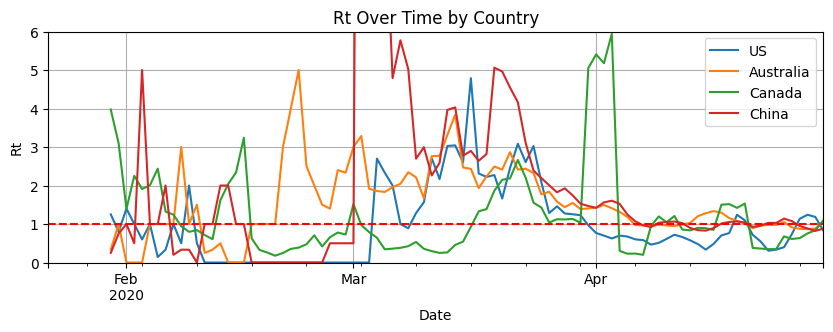

In [33]:
def mkframe(countries):
    frames = []
    for country in countries:
        inner_df = pd.DataFrame({
            'infected': infected.loc[country],
            'country': country
        })
        inner_df.index = pd.to_datetime(inner_df.index)
        frames.append(inner_df)
    df = pd.concat(frames)
    return df
df = mkframe(['US', 'Australia', 'Canada', 'China'])
df['new_infected'] = df.groupby('country')['infected'].diff()
df['Rt'] = (
    df.groupby('country')['new_infected']
      .rolling(8)
      .apply(lambda x: x[4:].sum() / x[:4].sum(), raw=True)
      .reset_index(level=0, drop=True)
)

plot_df = (
    df[df.index < "2020-05-01"]
    .replace(np.inf, np.nan)
)

fig, ax = plt.subplots(figsize=(10,3))

for country in plot_df['country'].unique():
    country_df = plot_df[plot_df['country'] == country]

    country_df['Rt'].fillna(method='pad').plot(
        ax=ax,
        label=country
    )
ax.set_ylim([0,6])
ax.axhline(1, linestyle='--', color='red')
plt.xlabel('Date')
plt.ylabel('Rt')
plt.title('Rt Over Time by Country')
plt.legend()
plt.grid(True)

plt.show()

Question 2: See how the number of deaths and recoveries correlate with number of infected cases.

The mean correlation between infected and recovered is:  -0.3080544970906106


c:\Users\Owner\.conda\envs\data_science_project\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Owner\.conda\envs\data_science_project\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


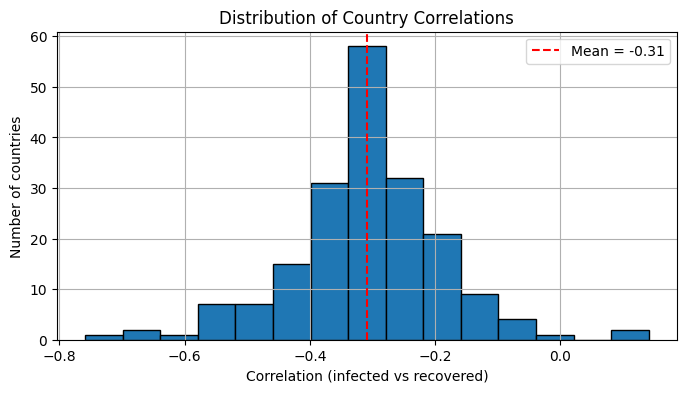

In [61]:
df = pd.DataFrame({
    'infected': infected.stack(),
    'recovered': recovered.stack()
}).dropna()

result = df.groupby('Country/Region').apply(
    lambda x: x['infected'].corr(x['recovered'])
)
print('The mean correlation between infected and recovered is: ', result.mean())
plt.figure(figsize=(8,4))
plt.hist(result.values, bins=15, edgecolor='black')
plt.axvline(result.mean(), color='red', linestyle='--', label=f"Mean = {result.mean():.2f}")
plt.xlabel("Correlation (infected vs recovered)")
plt.ylabel("Number of countries")
plt.title("Distribution of Country Correlations")
plt.legend()
plt.grid(True)
plt.show()

The mean correlation between infected and died is:  0.963346618291972


c:\Users\Owner\.conda\envs\data_science_project\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Owner\.conda\envs\data_science_project\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


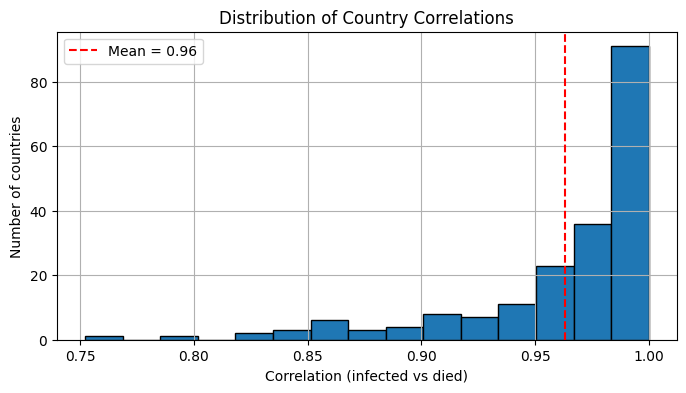

In [63]:
df = pd.DataFrame({
    'infected': infected.stack(),
    'died': deaths.stack()
}).dropna()

result = df.groupby('Country/Region').apply(
    lambda x: x['infected'].corr(x['died'])
)
print('The mean correlation between infected and died is: ', result.mean())
plt.figure(figsize=(8,4))
plt.hist(result.values, bins=15, edgecolor='black')
plt.axvline(result.mean(), color='red', linestyle='--', label=f"Mean = {result.mean():.2f}")
plt.xlabel("Correlation (infected vs died)")
plt.ylabel("Number of countries")
plt.title("Distribution of Country Correlations")
plt.legend()
plt.grid(True)
plt.show()

Question 3: Find out how long a typical disease lasts by visually correlating infection rate and deaths rate and looking for some anomalies. You may need to look at different countries to find that out.

C:\Users\Owner\AppData\Local\Temp\ipykernel_17240\212642499.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index)


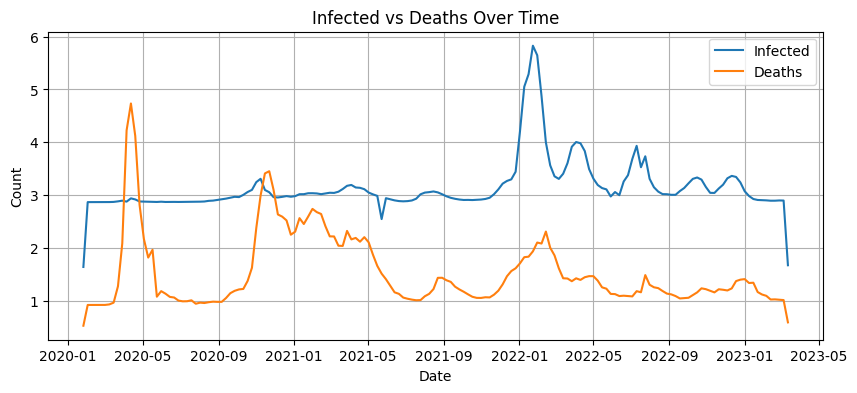

In [86]:
def mkframe(country):
    df = pd.DataFrame({ 'infected' : infected.loc[country],
                        'deaths' : deaths.loc[country],
                         })
    df.index = pd.to_datetime(df.index)
    return df

df = mkframe('France')
df
df['new_infected'] = df['infected'].diff()
df['new_deaths'] = df['deaths'].diff()

df[['new_infected', 'new_deaths']] = (
    df[['new_infected', 'new_deaths']] - df[['new_infected', 'new_deaths']].min()
) / (
    df[['new_infected', 'new_deaths']].max() - df[['new_infected', 'new_deaths']].min()
)

df = df.resample('W').sum()
# df = df.loc["2022-01-01":"2022-05-01"]

plt.figure(figsize=(10,4))

plt.plot(df.index, df['new_infected'], label='Infected')
plt.plot(df.index, df['new_deaths'], label='Deaths')

plt.xlabel('Date')
plt.ylabel('Count')
plt.title(f'Infected vs Deaths Over Time')
plt.legend()
plt.grid(True)

plt.show()

In the Exercise i normalized the new infected and deaths because the gap was to big to visualize correlation between them and you can see that in different countries the correlation is quicker then other countries but it's usually between 7-14 days.

Question 4: Calculate the fatality rate and how it changes over time. You may want to take into account the length of the disease in days to shift one time series before doing calculations

C:\Users\Owner\AppData\Local\Temp\ipykernel_17240\1260256016.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index)


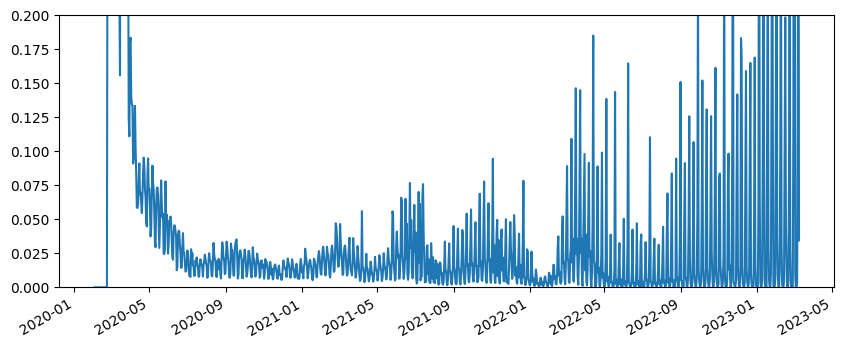

In [133]:
def mkframe(country):
    df = pd.DataFrame({'infected': infected.loc[country],
                       'deaths': deaths.loc[country]
    })
    df.index = pd.to_datetime(df.index)

    df['new_infected'] = df['infected'].diff()
    df['new_deaths'] = df['deaths'].diff()
    df['new_infected'] = df['new_infected'].clip(lower=0)
    df['new_deaths'] = df['new_deaths'].clip(lower=0)
    df['fatality'] = df['new_deaths'] / df['new_infected'].shift(10)
    df = df.replace([float('inf'), -float('inf')], None).dropna()

    return df


df = mkframe('US')

df['fatality'].plot(figsize=(10,4))
plt.ylim(0, 0.2)
plt.show()

I shifted the death to come 10 days the infected.

COVID-19 Papers Analysis


In the notebook-papers.ipynb file